In [2]:
from lz78 import Sequence, CharacterMap, LZ78SPA, spa_from_file
import numpy as np
from os import makedirs
import time
import pandas as pd
import random
import argparse
import math
import itertools
from memory_profiler import profile
import os
from ushuffle import shuffle, Shuffler
from dataclasses import dataclass, field
import argparse
from sys import stdout
from glob import glob
import re

from tqdm import tqdm

import matplotlib.pyplot as plt

In [3]:
@dataclass
class DataSet:
    val_path: str
    train_path: str
    spa_paths: list[str]
    name:  str

In [4]:
# Change these if needed
GUE_DIR = "GUE"
BEST_SPAS_DIR = "public_results/best_spas"

In [5]:
DATA: list[DataSet] = []
for path in sorted(glob(f"{GUE_DIR}/*/*/dev.csv")):
    stem = re.sub(r'[/]', '_', path[len("GUE/"): -len("/dev.csv")])
    train_path = path[:-len("dev.csv")] + "train.csv"

    if "fungi" in stem or "virus_species_40" in stem:
        continue

    spas = sorted(glob(f"{BEST_SPAS_DIR}/{stem}_*.bin"))
    if len(spas) > 0:
        DATA.append(
            DataSet(
                train_path=train_path,
                val_path=path,
                spa_paths=spas,
                name=stem
            )
        )

In [6]:
def handle_N(data):
    new_data = []
    for _, row in data.iterrows():
        sequence, label = row['sequence'], row['label']
        processed_sequences =["".join(char for char in sequence if char in "ACGT")]
        
        for proc_seq in processed_sequences:
            new_data.append({"sequence": proc_seq, "label": label})
    return pd.DataFrame(new_data) 

In [ ]:
@dataclass
class LogLossInfo:
    gap_when_correct: list[float] = field(default_factory=list)
    gap_when_incorrect: list[float] = field(default_factory=list)
    mean_log_loss_when_correct: list[float] = field(default_factory=list)
    std_log_loss_when_correct: list[float] = field(default_factory=list)
    mean_log_loss_of_correct_label_when_incorrect: list[float] = field(default_factory=list)
    std_log_loss_of_correct_label_when_incorrect: list[float] = field(default_factory=list)

    def add_entry(
        self,
        gap: float,
        mean_log_loss: float,
        std_log_loss: float,
        correct: bool,
    ):
        if correct:
            self.gap_when_correct.append(gap)
            self.mean_log_loss_when_correct.append(mean_log_loss)
            self.std_log_loss_when_correct.append(std_log_loss)
        else:
            self.gap_when_incorrect.append(gap)
            self.mean_log_loss_of_correct_label_when_incorrect.append(mean_log_loss)
            self.std_log_loss_of_correct_label_when_incorrect.append(std_log_loss)

def get_log_loss_gaps(
    data, spas, n_threads=32
):
    labels = data["label"]
    data = [Sequence(seq, charmap=CharacterMap("ACGT")) for seq in data["sequence"]]
    result = LogLossInfo()

    log_losses = np.zeros((len(spas), len(data)))
    std_log_losses = np.zeros((len(spas), len(data)))
    
    for i in range(len(spas)):
        results = spas[i].compute_test_loss_parallel(data, num_threads=n_threads, output_per_symbol_losses=True)
        log_losses[i, :] = [res["avg_log_loss"] for res in results]
        std_log_losses[i, :] = [np.std(res["log_losses"]) for res in results]


    for i in range(len(data)):
        losses = log_losses[:, i]
        true_label = labels[i]
        predicted_label = np.argmin(losses)
        correct = (predicted_label == true_label)
        sorted_losses = np.sort(losses)

        result.add_entry(
            gap=sorted_losses[1] - sorted_losses[0] if correct else abs(losses[true_label] - sorted_losses[0]),
            mean_log_loss=log_losses[true_label, i],
            std_log_loss=std_log_losses[true_label, i],
            correct=correct
        )

    return result


In [ ]:
output_data = []

for dataset in tqdm(DATA):
    validation_data = handle_N(pd.read_csv(dataset.val_path))
    stdout.flush()
    spas = [
        spa_from_file(path) for path in dataset.spa_paths
    ]

    log_loss_info = get_log_loss_gaps(
        validation_data, spas
    )

    output_data.append({
        "name": dataset.name,
        "mean_gap_when_correct": np.mean(log_loss_info.gap_when_correct),
        "mean_gap_when_incorrect": np.mean(log_loss_info.gap_when_incorrect),
        "median_gap_when_correct": np.median(log_loss_info.gap_when_correct),
        "median_gap": np.median(log_loss_info.gap_when_correct + log_loss_info.gap_when_incorrect),
        "median_gap_when_incorrect": np.median(log_loss_info.gap_when_incorrect),
        "std_gap_when_correct": np.std(log_loss_info.gap_when_correct),
        "std_gap_when_incorrect": np.std(log_loss_info.gap_when_incorrect),
        "mean_log_loss_when_correct": np.mean(log_loss_info.mean_log_loss_when_correct),
        "std_log_loss_when_correct": np.mean(log_loss_info.std_log_loss_when_correct),
        "mean_log_loss_of_correct_label_when_incorrect": np.mean(log_loss_info.mean_log_loss_of_correct_label_when_incorrect),
        "std_log_loss_of_correct_label_when_incorrect": np.mean(log_loss_info.std_log_loss_of_correct_label_when_incorrect),
    })

 25%|██▌       | 7/28 [00:18<00:59,  2.85s/it]

In [9]:
df = pd.DataFrame(output_data)
df["num_classes"] = 2
# covid has 9 classes and splice has 3
df.loc[df["name"] == "virus_covid", "num_classes"] = 9
df.loc[df["name"] == "splice_reconstructed", "num_classes"] = 3
df

,name,mean_gap_when_correct,mean_gap_when_incorrect,median_gap_when_correct,median_gap_when_incorrect,std_gap_when_correct,std_gap_when_incorrect,mean_log_loss_when_correct,std_log_loss_when_correct,mean_log_loss_of_correct_label_when_incorrect,std_log_loss_of_correct_label_when_incorrect,num_classes
0,EMP_H3,0.035268,0.011729,0.030411,0.008159,0.031156,0.016252,1.917732,0.370183,1.946619,0.346223,2
1,EMP_H3K14ac,0.074259,0.024949,0.069074,0.016827,0.051333,0.024741,1.879304,0.438428,1.947628,0.456266,2
2,EMP_H3K36me3,0.095812,0.039293,0.090939,0.027638,0.060115,0.041371,1.859098,0.443934,1.934178,0.470514,2
3,EMP_H3K4me1,0.083888,0.038224,0.078949,0.026126,0.053722,0.037988,1.868141,0.444044,1.940671,0.464847,2
4,EMP_H3K4me2,0.073088,0.036500,0.068563,0.023580,0.046837,0.039053,1.878227,0.425145,1.937328,0.448678,2
5,EMP_H3K4me3,0.169298,0.056955,0.165135,0.039750,0.093662,0.055744,1.807984,0.548132,1.939613,0.578459,2
6,EMP_H3K79me3,0.035002,0.014464,0.032106,0.009914,0.027842,0.017770,1.911729,0.359083,1.937296,0.369871,2
7,EMP_H3K9ac,0.164344,0.060516,0.154303,0.033034,0.105820,0.068037,1.819457,0.556948,1.970802,0.581293,2
8,EMP_H4,0.027918,0.009782,0.024067,0.007394,0.023932,0.008653,1.921646,0.358272,1.948932,0.344256,2
9,EMP_H4ac,0.093631,0.031885,0.089933,0.021339,0.053933,0.032499,1.860453,0.442995,1.935925,0.470063,2


In [12]:
datasets = [
    "EMP_H3", "EMP_H3K14ac", "EMP_H3K36me3", "EMP_H3K4me1", "EMP_H3K4me2", "EMP_H3K4me3",
    "EMP_H3K79me3", "EMP_H3K9ac", "EMP_H4", "EMP_H4ac", "virus_covid", "mouse_0", "mouse_1",
    "mouse_2", "mouse_3", "mouse_4", "prom_prom_300_all","prom_prom_300_notata", "prom_prom_300_tata",
    "prom_prom_core_all", "prom_prom_core_notata", "prom_prom_core_tata", "splice_reconstructed",
    "tf_0", "tf_1", "tf_2", "tf_3", "tf_4"
]

dna_bert = list(map(float,
"""78.27 52.57 56.88 50.52 31.13 36.27 67.39 55.63 80.71 50.43
71.02 56.26 84.77 79.32 66.47 52.66 71.59 94.27 86.77 74.17
68.04 69.37 84.99 71.99 76.06 66.52 58.54 77.43""".split()))

lz78 = list(map(float,
"""76 84.7 78.39 66.19 67.8 77.96 77.33 73.31 77.33 79.69
72.39 50.71 70.44 73.16 56.82 38.21 68.11 76.52 25.97 53.91
57.58 50.14 38.63 60.38 65.1 58.06 42.98 72.19""".split()))

cnn = list(map(float,
"""61.52 29.73 38.6 26.06 25.76 20.52 46.3 40.03 62.34 25.54
22.23 31.14 59.74 63.15 45.48 27.18 75.78 85.14 70.3 58.07
60.09 69.33 76.79 53.95 63.2 45.22 29.84 61.48""".split()))

In [13]:
improvement = {
    datasets[i]: (lz78[i] - dna_bert[i]) / dna_bert[i] for i in range(len(datasets))
}
df["improvement"] = [improvement[name] for name in df["name"]]

improvement_cnn = {
    datasets[i]: (lz78[i] - cnn[i]) / cnn[i] for i in range(len(datasets))
}
df["improvement_cnn"] = [improvement_cnn[name] for name in df["name"]]

In [14]:
df["lz78_metric"] = [lz78[datasets.index(name)] for name in df["name"]]

In [67]:
# df["predictor"] = df["std_gap_when_correct"] / df["mean_gap_when_correct"]
# df["predictor"] = np.minimum(
#     df["std_log_loss_of_correct_label_when_incorrect"] / df["mean_log_loss_of_correct_label_when_incorrect"],
#     0.3
# )
df["predictor"] = df["median_gap_when_correct"]

In [1]:
# plot improvement vs. various things
plt.figure(figsize=(10, 6))
plt.grid(True)

plt.scatter(
    df["predictor"],
    df["improvement"],
    color='blue'
)
plt.ylabel("(LZ78 MCC or F1 - DNABERT MCC or F1)\ndivided by DNABERT MCC or F1", fontsize=16)
plt.xlabel("Median (LZ log loss for correct class - second lowest LZ log loss)\nwhen prediction is correct", fontsize=16)
# make fonts bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("LZ78 Improvement over DNABERT vs. Log Loss Gap Variability", fontsize=18)
plt.show()

NameError: name 'plt' is not defined

In [69]:
# predictor_variable = np.minimum(df["predictor"], 1)
predictor_variable = df["predictor"]

In [ ]:
# find correlation coeff
correlation = np.corrcoef(predictor_variable, df["improvement"])[0, 1]
print(f"Correlation coefficient: {correlation}")

Correlation coefficient: 0.48706027593133516


In [103]:
emp = DATA[1]
splice = DATA[21]

In [104]:
data = handle_N(pd.read_csv(splice.val_path))
stdout.flush()
spas = [
    spa_from_file(path) for path in splice.spa_paths
]

In [105]:
labels = data["label"]
data = [Sequence(seq, charmap=CharacterMap("ACGT")) for seq in data["sequence"]]

In [106]:
stdout.flush()
log_losses = np.zeros((len(spas), len(data)))
for i in range(len(spas)):
    log_losses[i, :] = [res["avg_log_loss"] for res in spas[i].compute_test_loss_parallel(data, num_threads=64)]
predictions = np.argmin(log_losses, axis=0)

In [185]:
i = 8
log_losses = spas[labels[i]].compute_test_loss_parallel([data[i]], num_threads=1, output_per_symbol_losses=True)[0]["log_losses"]

In [186]:
predictions[i], labels[i]

(np.int64(0), np.int64(1))

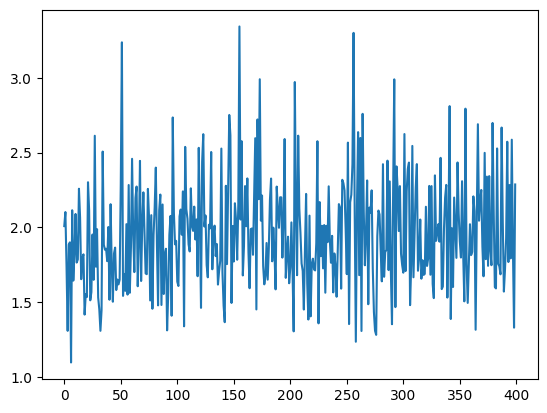

In [187]:
plt.plot(log_losses)